# 📘 Taller Evaluativo (20%) - Análisis de Portafolio
### Curso: Ingeniería Financiera / Programación  
### Herramienta: Google Colab  
---
### 🎯 Objetivo
Este taller busca que comprendas qué es un análisis de portafolio, cómo se calculan y analizan sus métricas (rentabilidad, riesgo y correlación), y cómo se interpreta el resultado para tomar decisiones de inversión.

👉 **Importante:** No basta con ejecutar el código. Debes **completar los espacios en blanco**, responder las **preguntas de investigación** y redactar un **análisis final**.

## 1. Importación de librerías
Primero, importa las librerías necesarias para trabajar con datos financieros.

In [98]:
# COMPLETAR: importa las librerías necesarias (yfinance, pandas, numpy, matplotlib, seaborn)
# Ejemplo: import yfinance as yf

# COMPLETAR AQUÍ

In [147]:
import yfinance as yf #Baja datos financieros desde YAhoo Finance
import pandas as pd #Manejo de dataframes
import numpy as np #Cálculos númericos y arrays
import matplotlib.pyplot as plt #Gráficas
import seaborn as sns #Mejora estilo de gráficas

## 2. Descarga de datos
Usa `yfinance` para descargar los precios de **Google (GOOG)**, **Amazon (AMZN)** y **Microsoft (MSFT)** durante los últimos 3 años. Utiliza la columna `Adj Close`.

🔎 **Pregunta:** ¿Por qué es más adecuado usar `Adj Close` que `Close` para un análisis financiero?

R// `Adj Close` no es una columna que se encuentre en la información descargada desde Yahoo Finance, y la forma correcta de analizar rendimientos es a través del precio de cierre `Close`

In [148]:
# COMPLETAR: descarga los precios de las acciones usando yf.download

In [149]:
acciones = ["GOOG", "AMZN", "MSFT"]

In [150]:
datos = yf.download(tickers=acciones)

/tmp/ipython-input-2201925341.py:1: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  3 of 3 completed


In [151]:
datos.head() # Veo los primeros 5 datos

Price            Close                                High              \
Ticker            AMZN        GOOG        MSFT        AMZN        GOOG   
Date                                                                     
2025-08-19  228.009995  202.309189  508.933350  230.529999  204.107569   
2025-08-20  223.809998  200.011230  504.890015  227.270004  201.989458   
2025-08-21  221.949997  200.440842  504.239990  222.779999  203.178400   
2025-08-22  228.839996  206.535400  507.230011  229.139999  209.043153   
2025-08-25  227.940002  208.973221  504.260010  229.600006  210.901490   

Price                          Low                                Open  \
Ticker            MSFT        AMZN        GOOG        MSFT        AMZN   
Date                                                                     
2025-08-19  514.314488  227.119995  200.750569  507.715351  230.089996   
2025-08-20  510.161348  220.919998  197.283673  503.612117  227.119995   
2025-08-21  507.630005  220.500000  200.221037  502.720001  222.649994   
2025-08-22  510.730011  220.820007  201.949503  502.410004  222.789993   
2025-08-25  508.190002  227.309998  205.766081  504.119995  227.350006   

Price                                 Volume                      
Ticker            GOOG        MSFT      AMZN      GOOG      MSFT  
Date                                                              
2025-08-19  203.722919  514.154777  29891000  13476600  21481000  
2025-08-20  201.499890  509.033198  36604300  13971700  27723000  
2025-08-21  200.540758  503.690002  32140500  11768900  18443300  
2025-08-22  203.777871  504.250000  37315300  25723700  24324200  
2025-08-25  206.815146  506.630005  22633700  22788800  21638600

In [152]:
datos.tail() # Veo los últimos 5 datos

Price            Close                                High              \
Ticker            AMZN        GOOG        MSFT        AMZN        GOOG   
Date                                                                     
2025-09-12  228.149994  241.380005  509.899994  230.789993  242.423004   
2025-09-15  231.429993  251.759995  515.359985  233.729996  252.750000   
2025-09-16  234.050003  251.419998  509.040009  235.899994  253.229996   
2025-09-17  231.619995  249.850006  510.019989  234.300003  251.949997   
2025-09-18  231.229996  252.330002  508.450012  233.479996  254.139999   

Price                          Low                                Open  \
Ticker            MSFT        AMZN        GOOG        MSFT        AMZN   
Date                                                                     
2025-09-12  512.549988  226.289993  238.500000  503.850006  230.350006   
2025-09-15  515.469971  230.320007  244.979996  507.000000  230.630005   
2025-09-16  517.229980  232.229996  249.714996  508.600006  232.940002   
2025-09-17  511.290009  228.710007  246.580002  505.929993  233.770004   
2025-09-18  513.070007  228.789993  250.110001  507.660004  232.500000   

Price                                 Volume                      
Ticker            GOOG        MSFT      AMZN      GOOG      MSFT  
Date                                                              
2025-09-12  240.800003  506.649994  38447500  14521900  23624900  
2025-09-15  245.139999  508.790009  33243300  29935200  17143800  
2025-09-16  252.330002  516.880005  38203900  24493500  19711900  
2025-09-17  251.460007  510.619995  42815200  20491300  15816600  
2025-09-18  251.860001  511.489990  37881200  21148400  18901300

In [154]:
datos = yf.download(tickers=acciones, period="3y")["Close"] #Descarga los precios de cierre de los últimos 3 años

/tmp/ipython-input-986915338.py:1: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  3 of 3 completed


In [155]:
datos.head() # Veo los primeros 5 datos

Ticker,AMZN,GOOG,MSFT
Date,,,
2022-09-19,124.660004,103.144157,238.584885
2022-09-20,122.190002,101.137894,236.565140
2022-09-21,118.540001,99.330254,233.150055
2022-09-22,117.309998,99.886444,235.130814
2022-09-23,113.779999,98.495964,232.145096


🔎 **Pregunta:** ¿Por qué es más adecuado usar `Adj Close` que `Close` para un análisis financiero?

**Repuesta** `Adj Close` no es una columna que se encuentre en la información descargada desde Yahoo Finance, y la forma correcta de analizar rendimientos es a través del precio de cierre `Close`

## 3. Visualización de precios
Grafica en una misma figura la evolución de los precios de cierre ajustados de las tres acciones.

🔎 **Pregunta:** ¿Cuál de las tres acciones muestra mayor crecimiento en estos 3 años?


In [156]:
# COMPLETAR: grafica las tres series de precios en una sola gráfica

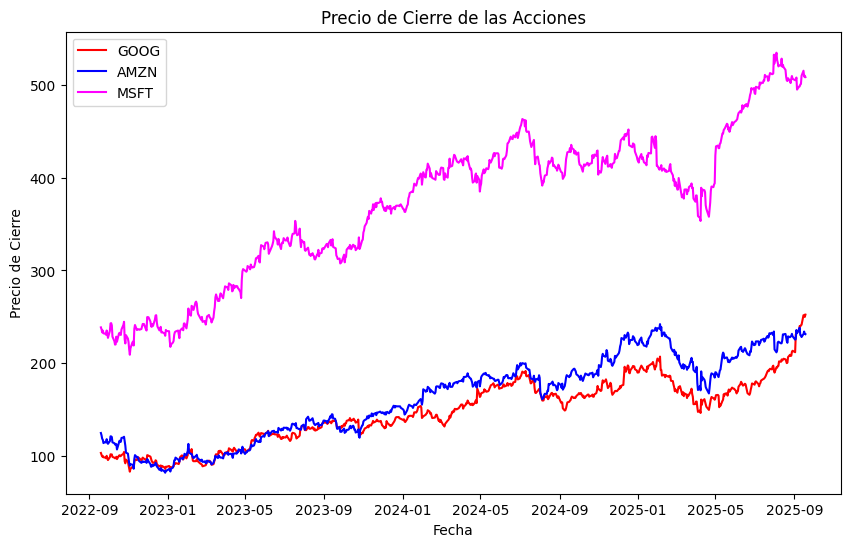

In [157]:
plt.figure(figsize=(10,6)) #Define el tamaño figura en pulgadas
plt.plot(datos["GOOG"], label="GOOG",color="red")
plt.plot(datos["AMZN"], label="AMZN",color="blue")
plt.plot(datos["MSFT"], label="MSFT", color="magenta")
plt.title("Precio de Cierre de las Acciones")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre")
plt.legend(acciones) #Añade las leyenda con los nombres de las acciones
plt.show()

In [158]:
#Librería para hacer gráfico estéticos e interactivos
import plotly.express as px

In [159]:
#Generamos gráfico interactivo
fig=px.line(datos) #Crea el gráfico pero no se visualiza
fig.show() #Permite visaulizar el gráfico

🔎 **Pregunta**: ¿Cuál de las tres acciones muestra mayor crecimiento en estos 3 años?

**R//** Visualmente podemos ver que la acción que muestra mayor crecimiento en los últimos tres años es Microsoft ´MSFT´, la cual tiene una tendencia positiva y mayor que las otras dos acciones analizadas.

## 4. Rentabilidades
Calcula las **rentabilidades logarítmicas diarias** y grafícalas.

🔎 **Pregunta:** ¿Qué diferencias encuentras entre observar precios y observar rentabilidades?



In [162]:
# COMPLETAR: calcula los rendimientos logarítmicos

rendimientos = np.log(datos / datos.shift(1)) #Fórmula estándar para calcular los rendimientos logarítmicos


In [163]:
rendimientos.head() #Muestra los 5 primeros datos

Ticker,AMZN,GOOG,MSFT
Date,,,
2022-09-19,NaN,NaN,NaN
2022-09-20,-0.020013,-0.019643,-0.008502
2022-09-21,-0.030327,-0.018035,-0.014541
2022-09-22,-0.010430,0.005584,0.008460
2022-09-23,-0.030553,-0.014018,-0.012779


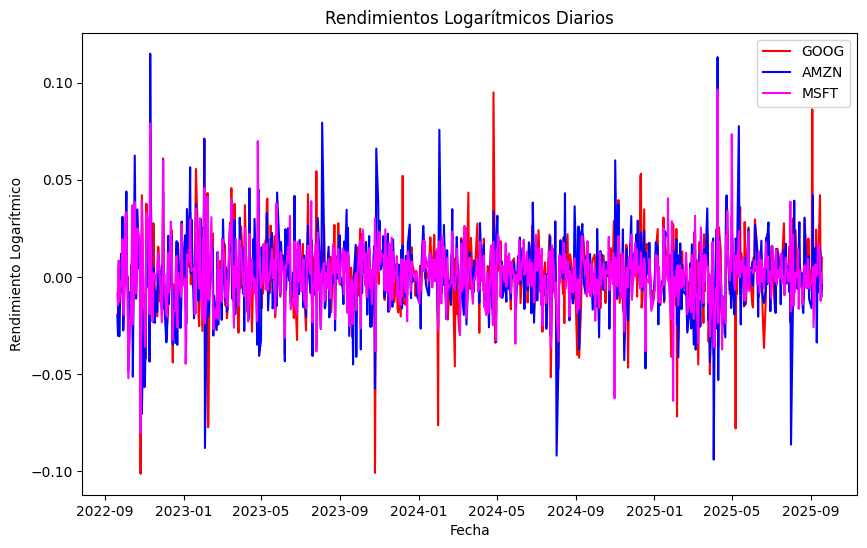

In [165]:
# Graficar rendimientos logarítmicos en el tiempo
plt.figure(figsize=(10,6))
plt.plot(rendimientos["GOOG"], label="GOOG", color="red")
plt.plot(rendimientos["AMZN"], label="AMZN", color="blue")
plt.plot(rendimientos["MSFT"], label="MSFT", color="magenta")

plt.title("Rendimientos Logarítmicos Diarios")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento Logarítmico")
plt.legend()
plt.show()

🔎 **Pregunta:** ¿Qué diferencias encuentras entre observar precios y observar rentabilidades?

**R//**
*   Observar precios: Muestra la evolución de la acción a través del tiempo, da respuesta a cual fue el precio de la acción en determinada fecha. Sirve para analizar tendencias de la acción.
*   Observar rentabilidades: Muestra los cambios relativos, en este caso del cambio del precio de la acción de hoy respecto a ayer; refleja volatilidades.

## 5. Medidas estadísticas
Calcula la **rentabilidad promedio** y la **volatilidad (desviación estándar)** de cada acción.

🔎 **Pregunta:** ¿Cuál acción es más riesgosa? ¿Cuál ofrece mayor retorno?

In [168]:
# COMPLETAR: calcula media y desviación estándar
media = rendimientos.mean()
volatilidad = rendimientos.std()

In [179]:
#Muestra la rentabilidad promedio diaria de cada acción
print("Rentabilidad promedio diaria:")
print(media)

Rentabilidad promedio diaria:
Ticker
AMZN    0.000822
GOOG    0.001190
MSFT    0.001006
dtype: float64


In [178]:
#Muestra la volatilidad diaria de cada acción
print("Volatilidad diaria:")
print(volatilidad)

Volatilidad diaria:
Ticker
AMZN    0.021280
GOOG    0.019836
MSFT    0.015977
dtype: float64


🔎 **Pregunta:** ¿Cuál acción es más riesgosa? ¿Cuál ofrece mayor retorno?

**R//** La acción más riesgosa es AMAZON, ya que su volatidad en mayor comparada con las otras dos acciones, es decir, presenta más fluctuaciones.

Y la acción con mejor retorno es GOOGLE que tiene un rendimiento promedio superior.

## 6. Correlación entre activos
Calcula y grafica la matriz de correlación entre las acciones.

🔎 **Pregunta:** ¿Qué significa que dos acciones tengan una correlación cercana a 1? ¿Y cercana a 0 o negativa?

In [189]:
# COMPLETAR: Calcula la correlación

correlacion = rendimientos.corr() #Calcula la correlación entre los rendimiento logaritmicos

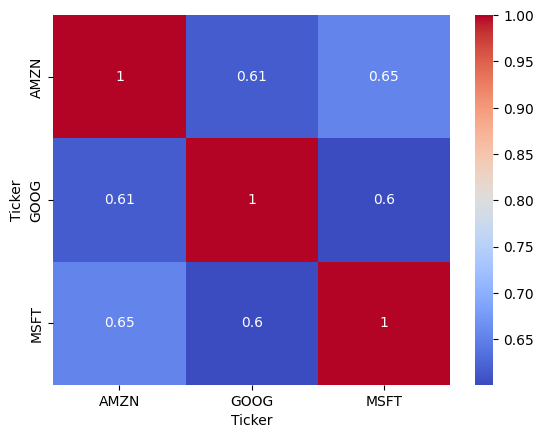

In [188]:
#Realiza un mapa de calor con seaborn
sns.heatmap(correlacion, annot=True, cmap="coolwarm")
plt.show()

¨**🔎 Pregunta:** ¿Qué significa que dos acciones tengan una correlación cercana a 1? ¿Y cercana a 0 o negativa?

**R//**
*   Correlación cercana a 1: Las acciones se mueven en la misma dirección, sea esta a la alza o a la baja.
*   Correlación cercana a 0: Las acciones se mueven de forma independiente, es decir, no existe relación entre el comportamiento de las acciones.
*   Correlación cercana a -1: Las acciones se mueven en direcciones opuesta, cuando una sube la otra suele bajar.



## 7. Portafolio simulado
Supón un portafolio con la siguiente distribución:
- 40% Google
- 30% Amazon
- 30% Microsoft

Calcula el **retorno esperado** y la **volatilidad del portafolio**.

🔎 **Preguntas:**
1. ¿Cómo interpretas el retorno esperado del portafolio?
2. ¿Qué efecto tuvo la diversificación sobre la volatilidad respecto a invertir en una sola acción?

In [ ]:
# COMPLETAR: cálculo del retorno y riesgo del portafolio

In [192]:
#Se asigna la distribución del portafolio

pesos = np.array([0.4, 0.3, 0.3])

In [194]:
#Cálculo del retorno esperado del portafolio = Rendimientos diarios * distribución del portafolio

retorno_portafolio = np.sum(rendimientos.mean() * pesos)

In [195]:
#Cálculo matriz de covarianza

matriz_covarianza = rendimientos.cov()

In [197]:
#Cálculo de la volatilidad del portafolio

vol_portafolio = np.sqrt(np.dot(pesos.T, np.dot(matriz_covarianza, pesos)))

In [201]:
#Muestra el retorno diario esperado del portafolio
print("Retorno esperado del portafolio (diario):", retorno_portafolio)

Retorno esperado del portafolio (diario): 0.0009873732674338302


In [202]:
#Muestra el riesgo diario del portafolio
print("Volatilidad del portafolio (diaria):", vol_portafolio)

Volatilidad del portafolio (diaria): 0.016753980553620606


🔎 **Preguntas:**

**¿Cómo interpretas el retorno esperado del portafolio?**
El retorno esperado diario del portafolio es de 0.000987 (~0.0987%), considerando la combinación de 40% Google, 30% Amazon y 30% Microsoft.
Este resultado implica que, en promedio, el portafolio aumentaría un 0.0987% por día bajo las condiciones históricas analizadas.

Al compararlo con las acciones individuales, el portafolio rinde más que Amazon, pero menos que Google y Microsoft. Esto refleja el efecto de ponderar activos con diferentes niveles de retorno: la inclusión de Amazon reduce ligeramente la rentabilidad global, aunque aporta diversificación.


**¿Qué efecto tuvo la diversificación sobre la volatilidad respecto a invertir en una sola acción?**

La volatilidad diaria del portafolio es de 0.01675 (~1.675%).

Es menor que la de Amazon (la acción más riesgosa) y que la de Google.

Es ligeramente mayor que la de Microsoft, que por sí sola ya ofrecía la mejor relación riesgo–retorno.

Esto muestra que la diversificación reduce el riesgo agregado en comparación con invertir únicamente en Amazon o Google. Aunque no logra superar la estabilidad de Microsoft, la cartera balancea riesgos y beneficios, suavizando los movimientos extremos y dando mayor consistencia al rendimiento.

## ✍️ **8. Conclusión final**
Redacta un análisis completo del portafolio respondiendo:
- **¿Qué acción fue más rentable y cuál más riesgosa?**

La acción con mayor rentabilidad promedio diaria fue Google, seguida de Microsoft y, finalmente, Amazon.

La acción más riesgosa resultó ser Amazon, con la mayor volatilidad diaria, mientras que la menos volátil fue Microsoft.

- **¿Qué tan correlacionadas están las acciones?**

Las correlaciones entre pares de acciones fueron positivas, lo que significa que tienden a moverse en la misma dirección.

- **¿Qué aportó la diversificación al portafolio?**

La diversificación ayudó a reducir el riesgo total. Al destinar el 40% del portafolio a GOOG (alta rentabilidad y menor volatilidad) y el 60% restante a AMZN y MSFT, se logró un equilibrio que disminuye la volatilidad frente a invertir en una sola acción.

- **Si fueras un inversionista, ¿invertirías en este portafolio? Justifica tu respuesta.**
No invertiría en este portafolio tal como está, ya que aunque ofrece un retorno atractivo y cierta diversificación, la alta concentración en Amazon y Microsoft incrementa el riesgo; lo ideal sería redistribuir los pesos dando mayor participación a Google, que muestra mejor equilibrio entre rentabilidad y volatilidad, logrando así un portafolio más eficiente y seguro.